# F4 · Clustering y PCA como contrastes de B-Call

## Objetivo
Evaluar la factibilidad y la estabilidad de dos métodos auxiliares, clustering jerárquico con
distancia nominal y PCA mediante SVD, y contrastarlos con B-Call sobre los diputados comunes.
También se repite B-Call sobre el universo restringido de cada método para separar el efecto
del método del efecto de la selección de personas.

## Entradas y organización
Se usan la matriz nominal y la ternaria de F4, el catálogo de votaciones de F3 y la tabla
principal de B-Call. Los cálculos se ejecutan con `AgrupamientoDiputados` (agrupamiento.py),
`PCASVD` (pca_svd.py), `SensibilidadClustering` (sensibilidad.py) y `comparar` /
`graficar_pca` (comparacion_metodos.py). Las salidas de los módulos se guardan en sus
ubicaciones oficiales y las propias del notebook en `F4/data/results/comparacion/` y
`F4/figures/comparacion/`.

### Cautelas de interpretación
- El análisis es descriptivo y se limita al proyecto de ley estudiado.
- La concordancia entre métodos que usan los mismos votos es evidencia interna del corpus, no una validación externa.
- Las etiquetas de los clusters (1 y 2) son neutrales; la interpretación ideológica requiere referencias externas.

## 1. Protocolo metodológico

**Pregunta auxiliar:** ¿el corpus permite recuperar agrupamientos y posiciones semejantes a B‑Call mediante procedimientos alternativos, y cuánto dependen de la cobertura y de las votaciones incluidas?

| Decisión | Clustering | PCA |
|---|---|---|
| Entrada | Sí, No y Abstención, como categorías distintas | Sí = +1, No = −1, Abstención = 0 |
| Columnas | Votaciones con más de una categoría observada | Votaciones con variación antes de seleccionar personas |
| Faltantes | Comparación exclusivamente sobre votos compartidos | Casos completos, sin imputación |
| Universo | Cobertura individual ≥ 80 % y todos los pares con cobertura ≥ 80 % | Personas sin NA en las columnas seleccionadas |
| Procedimiento | Hamming normalizada; enlace promedio | Centrado por columna, sin escalamiento; SVD |
| Resultado | Dos grupos; etiquetas neutrales | PC1, PC2, cargas y espectro de varianza |
| Comparación | ARI y correspondencia con grupos B‑Call | Pearson y Spearman de PC1 frente a d1 |
| Sensibilidad | Retiro individual, bloque y cobertura | Retiro individual y bloque; universo fijo y selección recalculada |

La cobertura usa como denominador las votaciones informativas del escenario. Mide disponibilidad de decisiones en el corpus, sin estimar asistencia ni elegibilidad. Se exige el mínimo entero $m=\lceil0{,}80J\rceil$, donde $J$ es la cantidad de votaciones informativas. Cada escenario recalcula ese denominador. Los umbrales de 40 %, 60 % y 100 % se usan como contrastes; 100 % representa casos completos.

El número de grupos se fija en dos para contrastar la partición binaria de B‑Call. No se estima como número óptimo de grupos de toda la actividad parlamentaria. La selección de casos completos puede modificar la composición del universo y se documenta expresamente.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.metadata as metadata
import json
import platform
import subprocess
import sys
import tomllib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.cluster.hierarchy import dendrogram

raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'pyproject.toml').is_file() and (p / 'F4/src/analisis').is_dir()), None)
if raiz is None:
    raise FileNotFoundError('Ejecuta el notebook dentro del repositorio.')
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
RAIZ = raiz
try:
    from F4.src.analisis import visualizacion as vis
    from F4.src.analisis.agrupamiento import AgrupamientoDiputados
    from F4.src.analisis.agrupamiento import guardar_resultados as guardar_agrupamiento
    from F4.src.analisis.pca_svd import PCASVD, ErrorPCA
    from F4.src.analisis.pca_svd import guardar_resultados as guardar_pca
    from F4.src.analisis.sensibilidad import SensibilidadClustering, _comparar_clusters
    from F4.src.analisis.comparacion_metodos import comparar, graficar_pca
    from F4.src.analisis.bcall import ModeloBCall
except ImportError as exc:
    raise ImportError("Se requieren los módulos de clustering, PCA, comparación y SensibilidadClustering.") from exc

RUTAS = {
    "nominal": "F4/data/processed/matriz_nominal.csv",
    "ternaria": "F4/data/processed/matriz_ternaria.csv",
    "bcall": "F4/data/results/individual/bcall/bcall_diputados.csv",
    "catalogo": "F3/data/processed/proyecto_ley_procesado.csv",
    "configuracion": "F4/config/analisis.toml",
}
for nombre, ruta in RUTAS.items():
    if not (RAIZ / ruta).is_file() or (RAIZ / ruta).stat().st_size == 0:
        raise FileNotFoundError(f"Entrada ausente o vacía: {ruta}")
with (RAIZ / RUTAS["configuracion"]).open("rb") as f:
    CONFIG = tomllib.load(f)

COBERTURA_BASE = 0.80
UMBRALES = (0.40, 0.60, 0.80, 1.00)
N_CLUSTERS = 2
N_COMPONENTES = 2
PIVOTE = CONFIG["orientacion"]["pivot"]
THRESHOLD_BCALL = CONFIG["bcall"]["threshold"]
DISTANCIA_BCALL = CONFIG["bcall"]["metodo_distancia"]
# Bloque de disposiciones del artículo 14 ter y del capítulo de la Agencia.
BLOQUES = {"articulos_206xx": tuple(str(v) for v in range(20629, 20638))}
# Tablas y figuras propias de este notebook, junto a las de comparacion_metodos.py.
RESULTADOS = RAIZ / "F4/data/results/comparacion"
FIGURAS = RAIZ / "F4/figures/comparacion"
# Salidas de los módulos: las mismas rutas que escriben sus scripts, sin copias.
SALIDAS_MODULOS = {
    "clustering": RAIZ / "F4/data/results/grupos",
    "sensibilidad_clustering": RAIZ / "F4/data/reports",
    "pca": RAIZ / "F4/data/results/individual/pca",
    "comparacion": RESULTADOS,
    "figura_comparacion": FIGURAS,
}
for carpeta in (RESULTADOS, FIGURAS, *SALIDAS_MODULOS.values()):
    carpeta.mkdir(parents=True, exist_ok=True)
# Convenciones visuales comunes (F4/src/analisis/visualizacion.py).
vis.aplicar_estilo()
figuras_generadas = []
pd.set_option("display.max_rows", 30)

def exportar(tabla, nombre):
    tabla.to_csv(RESULTADOS / nombre, index=False, lineterminator='\n')

def mostrar_figura(fig, nombre):
    vis.guardar(fig, FIGURAS / nombre, figuras_generadas)
    plt.show()
    plt.close(fig)

## 2. Fuentes y control de entrada

Las matrices provienen de F4 y conservan el corte analítico de F3. Los identificadores se normalizan para cruzar las matrices, el catálogo y las salidas B‑Call. Se verifica unicidad, correspondencia de ejes y equivalencia entre codificaciones antes de estimar modelos.

In [2]:
def cargar_matriz(ruta):
    tabla = pd.read_csv(RAIZ / ruta)
    if "diputado_id" not in tabla:
        raise ValueError(f"Falta diputado_id en {ruta}")
    tabla = tabla.set_index("diputado_id")
    tabla.columns = tabla.columns.map(str)
    if tabla.index.has_duplicates or tabla.columns.has_duplicates:
        raise ValueError(f"Identificadores duplicados en {ruta}")
    return tabla

nominal = cargar_matriz(RUTAS["nominal"])
ternaria = cargar_matriz(RUTAS["ternaria"])
bcall = pd.read_csv(RAIZ / RUTAS["bcall"])
catalogo = pd.read_csv(RAIZ / RUTAS["catalogo"])
catalogo["Id"] = catalogo["Id"].astype(str)
catalogo = catalogo.set_index("Id")
pd.testing.assert_index_equal(nominal.index, ternaria.index)
pd.testing.assert_index_equal(nominal.columns, ternaria.columns)
codigos = {"Sí": 1.0, "No": -1.0, "Abstención": 0.0}
if not set(nominal.stack().dropna()).issubset(codigos):
    raise ValueError("Hay categorías nominales no reconocidas.")
recodificada = nominal.apply(lambda col: col.map(codigos)).astype(float)
pd.testing.assert_frame_equal(recodificada, ternaria.astype(float))
if not set(nominal.columns).issubset(catalogo.index):
    raise ValueError("El catálogo no cubre todas las votaciones de las matrices.")
if bcall["diputado_id"].duplicated().any():
    raise ValueError("La salida B-Call contiene personas duplicadas.")
J = list(ternaria.columns[ternaria.nunique(dropna=True).gt(1)])
for nombre, ids in BLOQUES.items():
    if not set(ids).issubset(nominal.columns):
        raise ValueError(f"El bloque {nombre} no pertenece al corte analítico.")

control = pd.DataFrame([
    {"concepto": "Diputados en las matrices", "valor": len(nominal)},
    {"concepto": "Votaciones del corpus", "valor": nominal.shape[1]},
    {"concepto": "Decisiones observadas", "valor": int(nominal.notna().sum().sum())},
    {"concepto": "Celdas sin decisión", "valor": int(nominal.isna().sum().sum())},
    {"concepto": "Votaciones informativas", "valor": len(J)},
    {"concepto": "Proyectos de ley", "valor": catalogo.loc[nominal.columns, "numero_boletin"].nunique()},
])
display(control)
exportar(control, "control_entrada.csv")
fuentes = catalogo.loc[nominal.columns, ["numero_boletin", "Fecha", "TipoVotacionProyectoLey", "TramiteConstitucional", "Articulo"]].rename_axis("votacion_id").reset_index()
display(fuentes[["votacion_id", "numero_boletin", "Fecha", "TipoVotacionProyectoLey", "TramiteConstitucional"]])
exportar(fuentes, "catalogo_votaciones.csv")

,concepto,valor
0,Diputados en las matrices,151
1,Votaciones del corpus,15
2,Decisiones observadas,1993
3,Celdas sin decisión,272
4,Votaciones informativas,13
5,Proyectos de ley,1


,votacion_id,numero_boletin,Fecha,TipoVotacionProyectoLey,TramiteConstitucional
0,20627,11092-07,2023-05-08 19:05:22,General,Segundo Trámite
1,20628,11092-07,2023-05-08 19:06:49,General,Segundo Trámite
2,20629,11092-07,2023-05-08 19:08:21,Particular,Segundo Trámite
3,20630,11092-07,2023-05-08 19:09:23,Particular,Segundo Trámite
4,20631,11092-07,2023-05-08 19:10:13,Particular,Segundo Trámite
5,20632,11092-07,2023-05-08 19:11:06,Particular,Segundo Trámite
6,20633,11092-07,2023-05-08 19:11:56,Particular,Segundo Trámite
7,20634,11092-07,2023-05-08 19:12:58,Particular,Segundo Trámite
8,20635,11092-07,2023-05-08 19:13:51,Particular,Segundo Trámite
9,20636,11092-07,2023-05-08 19:15:04,Particular,Segundo Trámite


## 3. Universos y cobertura

Las filas observadas no equivalen a observaciones legislativas independientes: varios votos pertenecen a disposiciones del mismo proyecto y a la misma sesión. Por ello se informa tanto la cantidad de personas como la cantidad y concentración temática de votaciones.

,n_decisiones,diputados
0,1,16
1,12,28
2,13,107


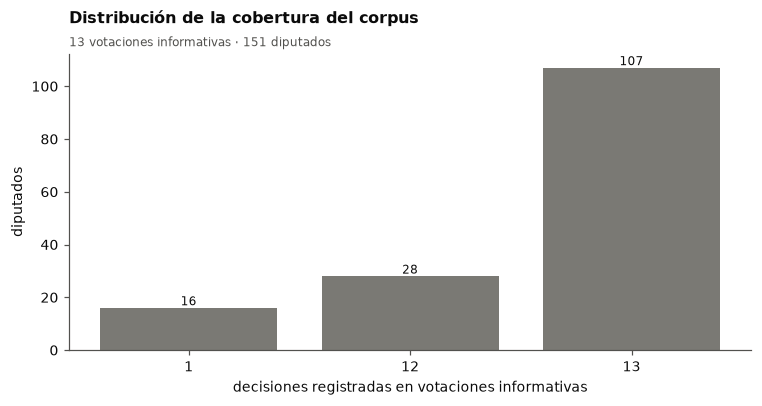

In [3]:
conteos = ternaria[J].notna().sum(axis=1)
cobertura = pd.DataFrame({"diputado_id": ternaria.index, "n_decisiones": conteos.to_numpy(),
                          "n_votaciones_informativas": len(J), "cobertura_corpus": conteos.to_numpy() / len(J)})
exportar(cobertura, "cobertura_informativa.csv")
distribucion = conteos.value_counts().sort_index().rename_axis("n_decisiones").reset_index(name="diputados")
display(distribucion)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(distribucion.n_decisiones.astype(str), distribucion.diputados, color=vis.NEUTRO)
for i, n in enumerate(distribucion.diputados):
    ax.text(i, n + 1, str(n), ha="center", fontsize=8, color=vis.TEXTO)
ax.set(xlabel="decisiones registradas en votaciones informativas", ylabel="diputados")
vis.titulo(ax, "Distribución de la cobertura del corpus",
           f"{len(J)} votaciones informativas · {len(ternaria)} diputados")
mostrar_figura(fig, "01_cobertura.png")

## 4. Clustering jerárquico

Para los diputados $i$ y $h$, con conjunto de votaciones compartidas $C_{ih}$, la distancia nominal es

$$d_{ih}=\frac{\sum_{j\in C_{ih}}\mathbb{1}(v_{ij}\ne v_{hj})}{|C_{ih}|}.$$

Sí, No y Abstención son categorías distintas. La distancia no presupone un orden entre ellas. El enlace promedio une grupos a partir de la media de las distancias entre sus integrantes. La matriz debe ser simétrica, finita y tener diagonal cero; no se imputan distancias. Las etiquetas 1 y 2 son identificadores neutrales.

,diputados,cobertura_minima
cluster,,
1,93,0.923077
2,42,0.923077


**Universo:** 135 diputados; **mínimo de co-votos exigido:** 11; **mínimo observado entre pares:** 12.

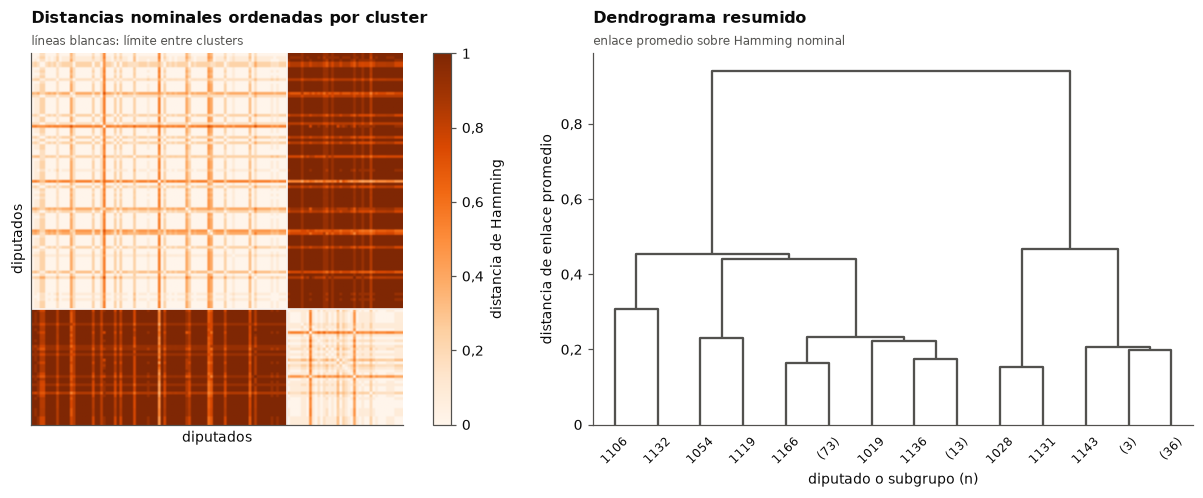

In [4]:
agrupamiento = AgrupamientoDiputados(cobertura_minima=COBERTURA_BASE, n_clusters=N_CLUSTERS).calcular(nominal)
clusters = agrupamiento.diputados
guardar_agrupamiento(agrupamiento, SALIDAS_MODULOS["clustering"])
universo_c = clusters.diputado_id.tolist()
observacion = nominal.loc[universo_c, list(agrupamiento.votaciones_incluidas)].notna().to_numpy(dtype=int)
covotos = observacion @ observacion.T
minimo_real = int(covotos[np.triu_indices(len(covotos), 1)].min())
tabla_clusters = clusters.groupby("cluster").agg(diputados=("diputado_id", "size"),
                                                 cobertura_minima=("cobertura_corpus", "min"))
display(tabla_clusters)
display(Markdown(f"**Universo:** {len(clusters)} diputados; **mínimo de co-votos exigido:** {agrupamiento.min_covotos}; **mínimo observado entre pares:** {minimo_real}."))
orden = clusters.sort_values(["cluster", "diputado_id"]).diputado_id
matriz_d = agrupamiento.matriz_hamming.loc[orden, orden]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
imagen = axes[0].imshow(matriz_d.to_numpy(), vmin=0, vmax=1, cmap=vis.SECUENCIAL, aspect="equal")
axes[0].set(xlabel="diputados", ylabel="diputados", xticks=[], yticks=[])
vis.titulo(axes[0], "Distancias nominales ordenadas por cluster", "líneas blancas: límite entre clusters")
barra = fig.colorbar(imagen, ax=axes[0], label="distancia de Hamming")
vis.formato_coma(barra.ax, "y")
corte = int(tabla_clusters.iloc[0].diputados)
axes[0].axhline(corte - .5, color="white", lw=1)
axes[0].axvline(corte - .5, color="white", lw=1)
dendrogram(agrupamiento.enlace, truncate_mode="lastp", p=14, show_leaf_counts=True,
           color_threshold=0, above_threshold_color=vis.TEXTO_SECUNDARIO,
           labels=[str(i) for i in universo_c], leaf_rotation=45, leaf_font_size=8, ax=axes[1])
axes[1].set(xlabel="diputado o subgrupo (n)", ylabel="distancia de enlace promedio")
vis.formato_coma(axes[1], "y")
vis.titulo(axes[1], "Dendrograma resumido", "enlace promedio sobre Hamming nominal")
fig.tight_layout()
mostrar_figura(fig, "02_clustering.png")

### 4.1. Estabilidad del clustering

Se recalcula el modelo al retirar una votación por vez, al retirar conjuntamente el bloque `20629`–`20637` y al variar el filtro de cobertura. El ARI se calcula sobre diputados comunes: 1 representa particiones idénticas; 0 corresponde a la concordancia esperada bajo el ajuste por azar y los valores negativos indican menor concordancia.

Para localizar cambios individuales se alinean etiquetas por máximo solapamiento. Las entradas y salidas del universo se registran aparte. Si varias alineaciones empatan, los cambios individuales tienen correspondencia ambigua; el ARI conserva su significado. Un escenario no estimable conserva su causa y no se sustituye por ARI = 0.

El bloque contiene nueve de las trece votaciones informativas. Su retiro es una perturbación sustantiva de la agenda y complementa, sin equivaler a ella, la evaluación de retiros individuales.

Calculando escenarios de sensibilidad de clustering...


,escenario,n_diputados_alternativo,n_comunes,n_entran,n_salen,ari,n_cambios_grupo,alineacion_ambigua,razon_NA
0,base,135,135,0,0,1.000000,0,False,None
1,retiro_votacion:20627,135,135,0,0,1.000000,0,False,None
2,retiro_votacion:20628,135,135,0,0,1.000000,0,False,None
3,retiro_votacion:20629,135,135,0,0,0.969856,1,False,None
4,retiro_votacion:20630,135,135,0,0,1.000000,0,False,None
5,retiro_votacion:20631,135,135,0,0,1.000000,0,False,None
6,retiro_votacion:20632,135,135,0,0,0.969856,1,False,None
7,retiro_votacion:20633,135,135,0,0,0.969856,1,False,None
8,retiro_votacion:20634,135,135,0,0,1.000000,0,False,None
9,retiro_votacion:20635,135,135,0,0,0.969856,1,False,None


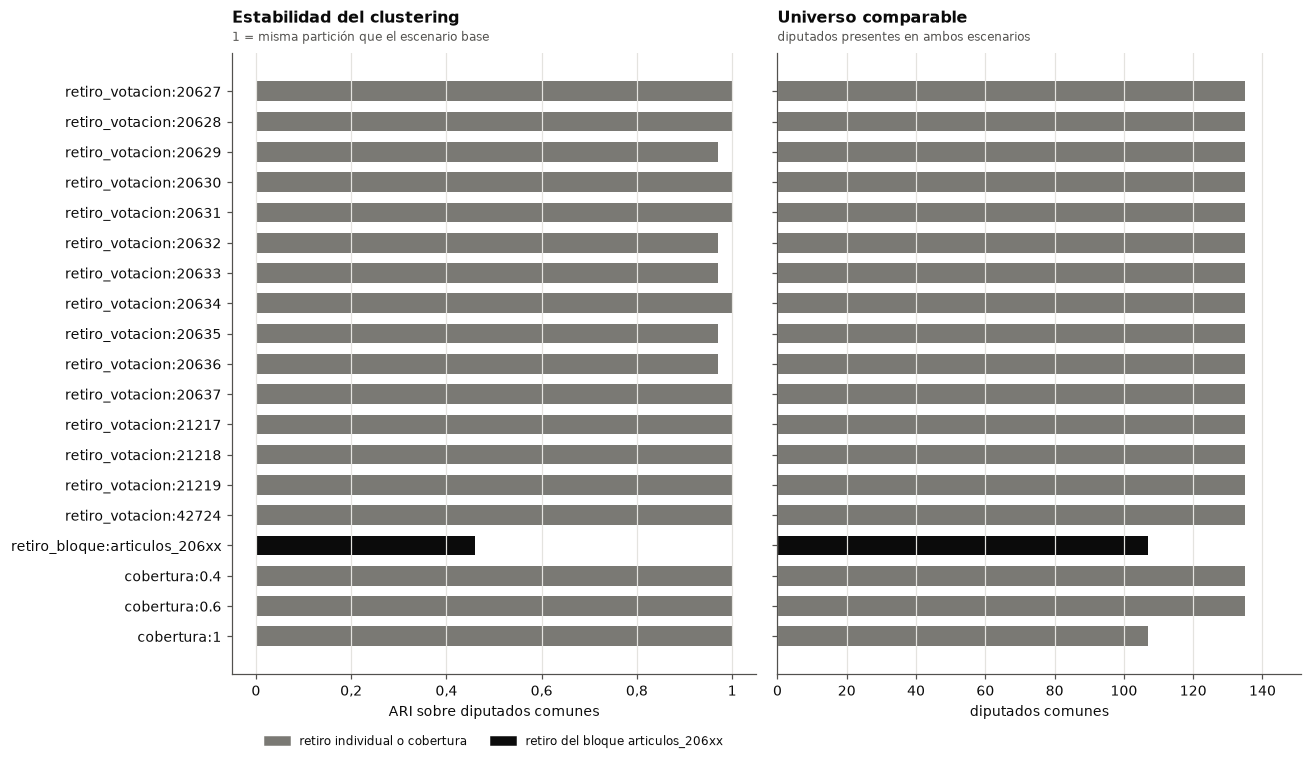

,escenario,diputado_id,cluster_base,cluster_alternativo_alineado
469,retiro_votacion:20629,1106,1,2
874,retiro_votacion:20632,1106,1,2
1009,retiro_votacion:20633,1106,1,2
1279,retiro_votacion:20635,1106,1,2
1414,retiro_votacion:20636,1106,1,2
2165,retiro_bloque:articulos_206xx,953,1,2
2166,retiro_bloque:articulos_206xx,971,1,2
2172,retiro_bloque:articulos_206xx,999,1,2
2180,retiro_bloque:articulos_206xx,1019,1,2
2193,retiro_bloque:articulos_206xx,1046,1,2


Los retiros individuales producen ARI entre **0.970 y 1.000**. El retiro del bloque produce **ARI = 0.461** sobre **107** diputados comunes, con **17** cambios de grupo y **28** salidas del universo.

In [5]:
print("Calculando escenarios de sensibilidad de clustering...")
sens_c = SensibilidadClustering(cobertura_base=COBERTURA_BASE, umbrales_cobertura=UMBRALES,
                              n_clusters=N_CLUSTERS).calcular(nominal, bloques=BLOQUES)
sens_c.resumen.to_csv(SALIDAS_MODULOS["sensibilidad_clustering"] / "sensibilidad_clustering.csv",
                      index=False, lineterminator='\n')
sens_c.detalle.to_csv(
    SALIDAS_MODULOS["sensibilidad_clustering"] / "sensibilidad_clustering_diputados.csv",
    index=False,
    lineterminator='\n',
)
display(sens_c.resumen[["escenario", "n_diputados_alternativo", "n_comunes", "n_entran", "n_salen",
                       "ari", "n_cambios_grupo", "alineacion_ambigua", "razon_NA"]])
filas_grafico = sens_c.resumen.loc[sens_c.resumen.escenario.ne("base")]
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
y = np.arange(len(filas_grafico))
# El retiro del bloque se destaca en tinta: es una perturbación sustantiva de la agenda.
colores = [vis.TEXTO if "bloque" in s else vis.NEUTRO for s in filas_grafico.escenario]
axes[0].barh(y, filas_grafico.ari.astype(float), color=colores, height=0.65)
axes[0].set(yticks=y, yticklabels=filas_grafico.escenario, xlabel="ARI sobre diputados comunes",
            xlim=(-.05, 1.05))
axes[0].invert_yaxis()
axes[0].grid(axis="x")
vis.formato_coma(axes[0], "x")
vis.titulo(axes[0], "Estabilidad del clustering", "1 = misma partición que el escenario base")
axes[1].barh(y, filas_grafico.n_comunes.astype(float), color=colores, height=0.65)
axes[1].set(xlabel="diputados comunes", xlim=(0, len(clusters) * 1.12))
axes[1].grid(axis="x")
vis.titulo(axes[1], "Universo comparable", "diputados presentes en ambos escenarios")
vis.leyenda_inferior(axes[0], [vis.parche(vis.NEUTRO, "retiro individual o cobertura"),
                               vis.parche(vis.TEXTO, "retiro del bloque articulos_206xx")],
                     ncol=2, y=-0.08)
fig.tight_layout()
mostrar_figura(fig, "03_sensibilidad_clustering.png")
retiros_c = sens_c.resumen[sens_c.resumen.escenario.str.startswith("retiro_votacion:")]
bloque_c = sens_c.resumen[sens_c.resumen.escenario.str.startswith("retiro_bloque:")].iloc[0]
cambios_c = sens_c.detalle[sens_c.detalle.cambio_grupo.eq(True)]
display(cambios_c[["escenario", "diputado_id", "cluster_base", "cluster_alternativo_alineado"]])
display(Markdown(f"Los retiros individuales producen ARI entre **{retiros_c.ari.min():.3f} y {retiros_c.ari.max():.3f}**. "
                 f"El retiro del bloque produce **ARI = {bloque_c.ari:.3f}** sobre **{bloque_c.n_comunes}** diputados comunes, "
                 f"con **{bloque_c.n_cambios_grupo}** cambios de grupo y **{bloque_c.n_salen}** salidas del universo."))

## 5. PCA mediante SVD

Se seleccionan las votaciones con variación en el universo observado y luego los diputados sin faltantes en esas columnas. Para $n$ casos completos, la matriz centrada $X_c$ se descompone como

$$X_c=U\Sigma V^\top,\qquad T=X_cV,\qquad \lambda_k=\frac{s_k^2}{n-1},\qquad r_k=\frac{\lambda_k}{\sum_\ell\lambda_\ell}.$$

$T$ contiene las coordenadas, $V$ los coeficientes de los ejes, $s_k$ los valores singulares, $\lambda_k$ la varianza del componente y $r_k$ su proporción de varianza explicada. El archivo de **cargas** contiene coeficientes de $V$, no correlaciones variable–componente.

No se escalan columnas. La codificación ternaria representa la abstención entre Sí y No: es una decisión numérica del análisis y distingue PCA de la distancia nominal. El signo de cada eje es arbitrario; se conserva el signo original y se registra cualquier alineación usada para comparación. PC2 representa un segundo patrón de diferencias entre personas y no equivale a la variabilidad individual d2 de B‑Call.

,componente,autovalor,proporcion_varianza,proporcion_acumulada,coordenadas_exportadas
0,PC1,9.285796,0.856967,0.856967,True
1,PC2,0.785015,0.072447,0.929414,True
2,PC3,0.180547,0.016662,0.946076,False
3,PC4,0.168380,0.015539,0.961616,False
4,PC5,0.122981,0.011350,0.972966,False
5,PC6,0.101731,0.009389,0.982354,False
6,PC7,0.060661,0.005598,0.987952,False
7,PC8,0.051408,0.004744,0.992697,False
8,PC9,0.044313,0.004090,0.996786,False
9,PC10,0.014793,0.001365,0.998152,False


,votacion_id,PC1,PC2
0,20629,0.287290,-0.003511
1,20630,0.278676,-0.044755
2,20631,0.287416,-0.069175
3,20632,0.293644,-0.178270
4,20633,0.280117,-0.197375
5,20634,0.282181,-0.212717
6,20635,0.281852,-0.173999
7,20636,0.284484,-0.175738
8,20637,0.287219,-0.143462
9,21217,0.275829,-0.133896


,metodo,incluidos,excluidos,votaciones
0,Clustering,135,16,13
1,PCA,107,44,13


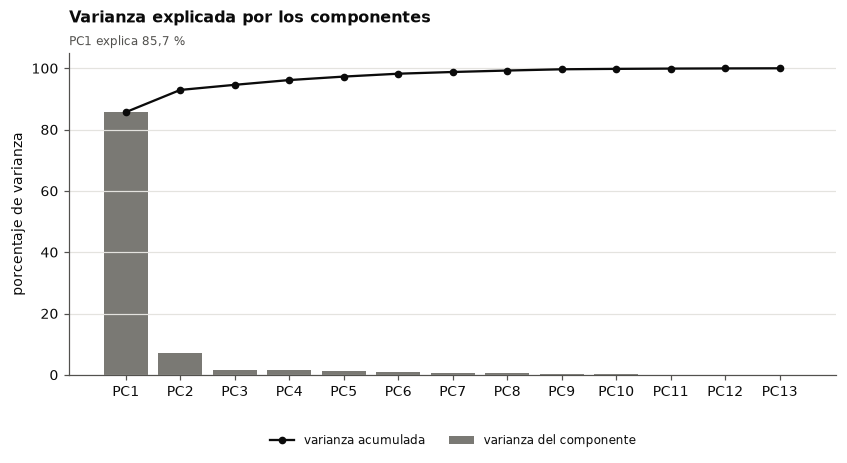

In [6]:
pca = PCASVD(n_componentes=N_COMPONENTES).calcular(ternaria)
guardar_pca(pca, SALIDAS_MODULOS["pca"])
comparaciones = comparar(bcall, clusters, pca.coordenadas)
for nombre, tabla in comparaciones.items():
    tabla.to_csv(SALIDAS_MODULOS["comparacion"] / nombre, index=False, lineterminator='\n')
resumen_comp = comparaciones["resumen_comparacion.csv"].iloc[0]
signo_pc1 = int(resumen_comp.signo_alineacion_pc1)
display(pca.varianza)
display(pca.cargas)
tabla_universos = pd.DataFrame([
    {"metodo": "Clustering", "incluidos": len(clusters), "excluidos": len(agrupamiento.exclusiones), "votaciones": len(agrupamiento.votaciones_incluidas)},
    {"metodo": "PCA", "incluidos": len(pca.coordenadas), "excluidos": len(pca.exclusiones), "votaciones": len(pca.medias)},
])
display(tabla_universos)
exportar(tabla_universos, "universos_metodos.csv")
fig, ax = plt.subplots(figsize=(9, 3.8))
pos = np.arange(len(pca.varianza))
ax.bar(pos, 100 * pca.varianza.proporcion_varianza, color=vis.NEUTRO, label="varianza del componente")
ax.plot(pos, 100 * pca.varianza.proporcion_acumulada, marker="o", ms=4, color=vis.TEXTO,
        label="varianza acumulada")
ax.set(xticks=pos, xticklabels=pca.varianza.componente, ylabel="porcentaje de varianza",
       ylim=(0, 105))
ax.grid(axis="y")
vis.titulo(ax, "Varianza explicada por los componentes",
           f"PC1 explica {vis.coma(100 * pca.varianza.iloc[0].proporcion_varianza, 1)} %")
vis.leyenda_inferior(ax, ncol=2, y=-0.15)
mostrar_figura(fig, "04_varianza_pca.png")

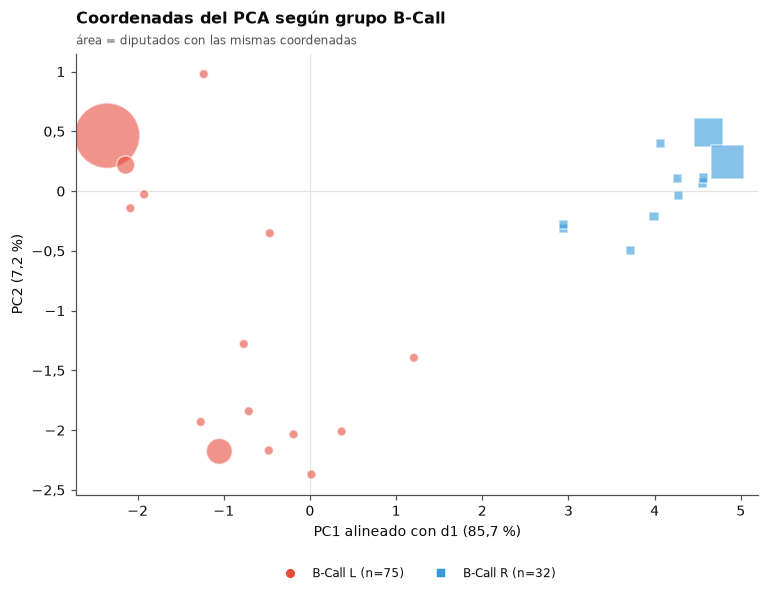

In [7]:
mapa_pca = pca.coordenadas.merge(bcall[["diputado_id", "grupo_bcall"]], on="diputado_id", validate="one_to_one")
mapa_pca["PC1_alineado"] = signo_pc1 * mapa_pca.PC1
mapa_pca["grupo_bcall"] = mapa_pca.grupo_bcall.fillna("Sin grupo")
puntos = mapa_pca.assign(x=mapa_pca.PC1_alineado.round(12), y=mapa_pca.PC2.round(12)).groupby(
    ["x", "y", "grupo_bcall"], as_index=False).size()
fig, ax = plt.subplots(figsize=(8, 5.2))
leyenda = []
for grupo, datos in puntos.groupby("grupo_bcall"):
    color, forma = vis.GRUPOS.get(grupo, vis.NEUTRO), vis.MARCADORES_GRUPO.get(grupo, "o")
    ax.scatter(datos.x, datos.y, s=36 * datos["size"], alpha=.6, color=color, marker=forma,
               edgecolors="white", linewidths=1)
    leyenda.append(vis.marcador(color, f"B-Call {grupo} (n={int(datos['size'].sum())})", forma))
ax.axhline(0, color=vis.GRILLA, lw=.8, zorder=0)
ax.axvline(0, color=vis.GRILLA, lw=.8, zorder=0)
ax.set(xlabel=f"PC1 alineado con d1 ({vis.coma(100 * pca.varianza.iloc[0].proporcion_varianza, 1)} %)",
       ylabel=f"PC2 ({vis.coma(100 * pca.varianza.iloc[1].proporcion_varianza, 1)} %)")
vis.formato_coma(ax, "x")
vis.formato_coma(ax, "y")
vis.titulo(ax, "Coordenadas del PCA según grupo B-Call",
           "área = diputados con las mismas coordenadas")
vis.leyenda_inferior(ax, leyenda, ncol=2, y=-0.14)
mostrar_figura(fig, "05_mapa_pca.png")

## 6. Concordancia con B‑Call

### 6.1. Resultados B‑Call de referencia

La partición se compara mediante ARI, independiente de las etiquetas de grupo. Para PC1 se conservan las coordenadas originales y se invierte el signo cuando su correlación con d1 es negativa. Esta operación cambia la orientación visual, no la estructura del PCA. Las correlaciones se calculan con cada diputado como unidad, incluidos los perfiles repetidos.

,resultado
n_comunes_clustering,135
ari_clustering_bcall,1.0
n_discrepancias_alineadas,0
alineacion_clusters_ambigua,False
n_comunes_pca,107
pearson_pc1_original_d1,-0.99988
signo_alineacion_pc1,-1
pearson_pc1_alineado_d1,0.99988
spearman_pc1_alineado_d1,0.998512
referencia_bcall,resultados_existentes_sin_reestimar


cluster,grupo_bcall,1,2
0,L,93,0
1,R,0,42


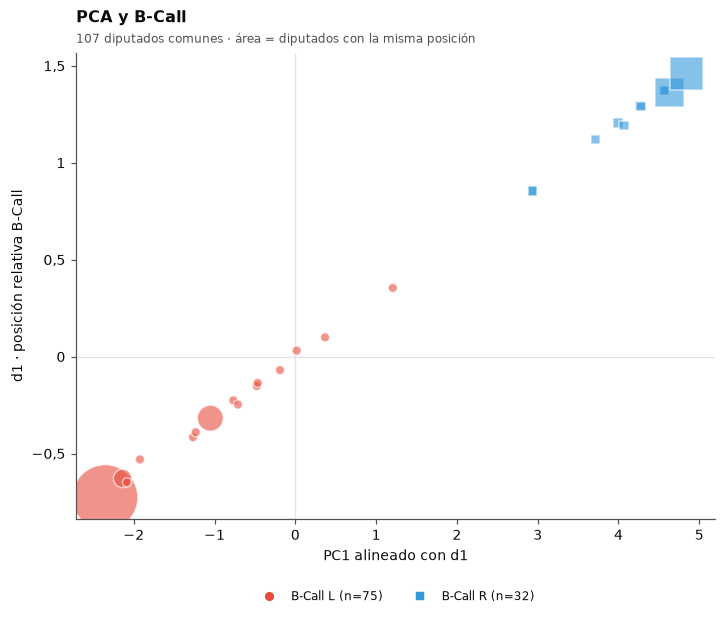

La partición nominal y B‑Call alcanzan **ARI = 1.000** sobre **135** diputados. PC1 y d1 presentan **Pearson = 0.999880** y **Spearman = 0.998512** sobre **107** diputados.

In [8]:
display(comparaciones["resumen_comparacion.csv"].T.rename(columns={0: "resultado"}))
display(comparaciones["correspondencia_clusters.csv"])
# Misma función que usa el script de comparación, con su ruta oficial.
mostrar_figura(graficar_pca(comparaciones["comparacion_pca_bcall.csv"]), "pc1_vs_d1.png")
display(Markdown(f"La partición nominal y B‑Call alcanzan **ARI = {resumen_comp.ari_clustering_bcall:.3f}** "
                 f"sobre **{resumen_comp.n_comunes_clustering}** diputados. PC1 y d1 presentan "
                 f"**Pearson = {resumen_comp.pearson_pc1_alineado_d1:.6f}** y "
                 f"**Spearman = {resumen_comp.spearman_pc1_alineado_d1:.6f}** "
                 f"sobre **{resumen_comp.n_comunes_pca}** diputados."))

### 6.2. B‑Call recalculado sobre universos restringidos

La comparación anterior utiliza los puntajes B‑Call existentes. Para controlar el efecto de seleccionar diputados, se recalcula B‑Call con las mismas personas y votaciones informativas de cada método, manteniendo el pivote, el método de distancia y el umbral nativo. Se recalculan agrupamiento, orientación y estandarización de B‑Call. Se registran tanto las concordancias con los métodos auxiliares como las diferencias respecto de la referencia.

In [9]:
referencia = bcall.set_index("diputado_id")
filas_restringidas = []
for nombre, ids in [("clustering", universo_c), ("pca", pca.coordenadas.diputado_id.tolist())]:
    if PIVOTE not in ids:
        raise ValueError(f"El pivote no está en el universo {nombre}.")
    entrada = ternaria.loc[ids, J]
    restringido = ModeloBCall().calcular_auto(entrada, pivot=PIVOTE,
        distance_method=DISTANCIA_BCALL, threshold=THRESHOLD_BCALL)
    tabla_r = restringido.diputados.copy()
    exportar(tabla_r.rename_axis("diputado_id").reset_index(), f"bcall_restringido_{nombre}.csv")
    comunes = tabla_r.index.intersection(referencia.index)
    valores = pd.DataFrame({"d1_referencia": referencia.loc[comunes, "d1"],
                            "d1_restringido": tabla_r.loc[comunes, "d1"]}).dropna()
    arigrupos, _, _ = _comparar_clusters(referencia.loc[comunes, "grupo_bcall"], tabla_r.loc[comunes, "grupo_bcall"])
    fila = {"universo": nombre, "diputados": len(tabla_r), "votaciones": entrada.shape[1],
            "ari_grupos_bcall_referencia_restringido": arigrupos,
            "pearson_d1_referencia_restringido": valores.d1_referencia.corr(valores.d1_restringido),
            "mediana_abs_cambio_d1": float((valores.d1_restringido-valores.d1_referencia).abs().median())}
    if nombre == "clustering":
        etiquetas_c = clusters.set_index("diputado_id").loc[tabla_r.index, "cluster"]
        fila["ari_clustering_bcall_restringido"] = _comparar_clusters(tabla_r.grupo_bcall, etiquetas_c)[0]
    else:
        pc1 = pca.coordenadas.set_index("diputado_id").loc[tabla_r.index, "PC1"]
        fila["pearson_abs_pc1_d1_restringido"] = abs(pc1.corr(tabla_r.d1))
        fila["spearman_abs_pc1_d1_restringido"] = abs(pc1.rank().corr(tabla_r.d1.rank()))
    filas_restringidas.append(fila)
control_universo = pd.DataFrame(filas_restringidas)
exportar(control_universo, "comparacion_bcall_restringido.csv")
display(control_universo.T)

,0,1
universo,clustering,pca
diputados,135,107
votaciones,13,13
ari_grupos_bcall_referencia_restringido,1.0,1.0
pearson_d1_referencia_restringido,1.0,0.999998
mediana_abs_cambio_d1,0.000542,0.007418
ari_clustering_bcall_restringido,1.0,NaN
pearson_abs_pc1_d1_restringido,NaN,0.99989
spearman_abs_pc1_d1_restringido,NaN,0.998512


## 7. Sensibilidad de PCA

Se estudia la estabilidad de PC1 al retirar cada votación informativa y el bloque de disposiciones. Se presentan dos diseños:

- **Universo fijo:** se mantienen los diputados completos del PCA base. Aísla el cambio de votaciones sobre esas mismas personas.
- **Selección recalculada:** se vuelve a seleccionar casos completos a partir de toda la matriz. Evalúa la aplicación completa del protocolo, registrando entradas y salidas.

En cada escenario se comparan las coordenadas sobre diputados comunes y se alinea el signo con PC1 base. Se informa correlación absoluta de Pearson, concordancia de orden, cantidad de personas y varianza explicada. No se establece un umbral universal de estabilidad ni se usan estas correlaciones como pruebas de ideología. La evaluación se concentra en PC1; la estabilidad de PC2 y de sus cargas no se equipara a la de PC1.

Las curvas de ambos diseños pueden superponerse. La tabla registra por separado el universo y las correlaciones de cada diseño.

,diseno,escenario,n_alternativo,n_comunes,pearson_abs_pc1,spearman_abs_pc1,varianza_pc1,razon_NA
0,universo_fijo,retiro_votacion:20629,107,107,0.999537,0.999724,0.854278,None
1,universo_fijo,retiro_votacion:20630,107,107,0.999344,0.998909,0.859147,None
2,universo_fijo,retiro_votacion:20631,107,107,0.999510,0.997748,0.854692,None
3,universo_fijo,retiro_votacion:20632,107,107,0.999718,1.000000,0.849880,None
4,universo_fijo,retiro_votacion:20633,107,107,0.999636,0.999890,0.852916,None
5,universo_fijo,retiro_votacion:20634,107,107,0.999513,0.999978,0.854902,None
6,universo_fijo,retiro_votacion:20635,107,107,0.999608,0.999460,0.853309,None
7,universo_fijo,retiro_votacion:20636,107,107,0.999671,0.998153,0.851820,None
8,universo_fijo,retiro_votacion:20637,107,107,0.999666,0.999915,0.851672,None
9,universo_fijo,retiro_votacion:21217,107,107,0.999668,0.998360,0.853118,None


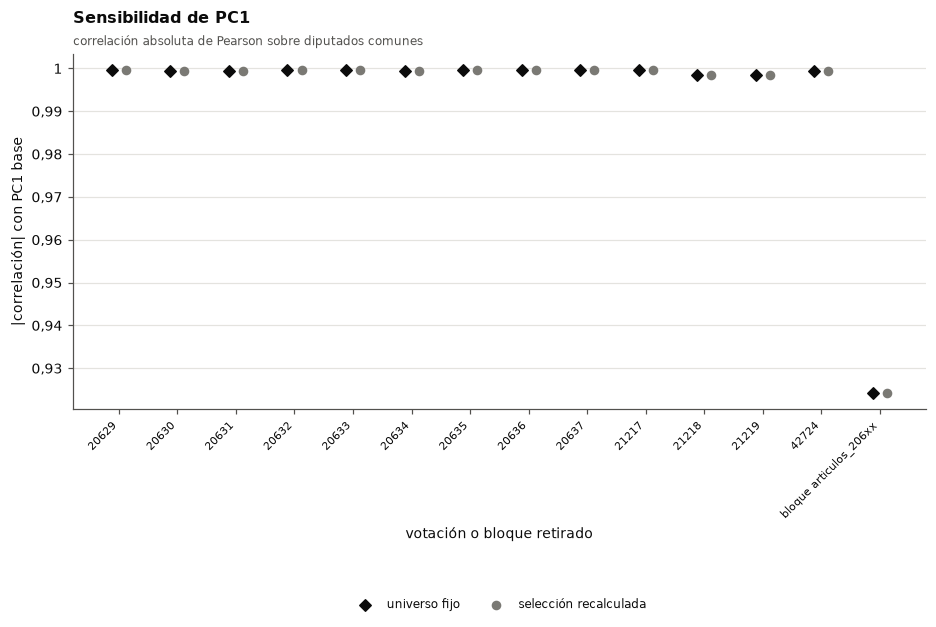

In [10]:
pc_base = pca.coordenadas.set_index("diputado_id").PC1
universo_p = pc_base.index
escenarios_p = [(f"retiro_votacion:{v}", (v,)) for v in J]
escenarios_p += [(f"retiro_bloque:{nombre}", ids) for nombre, ids in BLOQUES.items()]
filas_p, detalle_p, cargas_p = [], [], []
for diseno in ("universo_fijo", "seleccion_recalculada"):
    origen = ternaria.loc[universo_p, J] if diseno == "universo_fijo" else ternaria
    for escenario, retiradas in escenarios_p:
        fila = {"diseno": diseno, "escenario": escenario, "n_base": len(pc_base),
                "n_alternativo": pd.NA, "n_comunes": pd.NA, "n_entran": pd.NA, "n_salen": pd.NA,
                "pearson_abs_pc1": np.nan, "spearman_abs_pc1": np.nan,
                "varianza_pc1": np.nan, "varianza_pc1_pc2": np.nan,
                "n_votaciones": pd.NA, "estado": "NO_ESTIMABLE", "razon_NA": None}
        try:
            alt = PCASVD(n_componentes=N_COMPONENTES).calcular(origen.drop(columns=list(retiradas)))
        except ErrorPCA as exc:
            fila["razon_NA"] = str(exc); filas_p.append(fila); continue
        pc_alt = alt.coordenadas.set_index("diputado_id").PC1
        comunes = pc_base.index.intersection(pc_alt.index)
        r = pc_base.loc[comunes].corr(pc_alt.loc[comunes]) if len(comunes) >= 3 else np.nan
        signo = -1 if pd.notna(r) and r < 0 else 1
        rho = pc_base.loc[comunes].rank().corr(pc_alt.loc[comunes].rank()) if len(comunes) >= 3 else np.nan
        fila.update(n_alternativo=len(pc_alt), n_comunes=len(comunes),
                    n_entran=len(pc_alt.index.difference(pc_base.index)),
                    n_salen=len(pc_base.index.difference(pc_alt.index)),
                    pearson_abs_pc1=abs(r), spearman_abs_pc1=abs(rho),
                    varianza_pc1=alt.varianza.iloc[0].proporcion_varianza,
                    varianza_pc1_pc2=alt.varianza.iloc[1].proporcion_acumulada,
                    n_votaciones=len(alt.medias), estado="DESCRIPTIVO", signo_alineacion=signo)
        filas_p.append(fila)
        detalle_p.append(pd.DataFrame({"diputado_id": comunes, "diseno": diseno, "escenario": escenario,
                                      "PC1_base": pc_base.loc[comunes].to_numpy(),
                                      "PC1_alternativo_original": pc_alt.loc[comunes].to_numpy(),
                                      "PC1_alternativo_alineado": signo * pc_alt.loc[comunes].to_numpy()}))
        cargas_p.append(alt.cargas.assign(diseno=diseno, escenario=escenario))
sens_p = pd.DataFrame(filas_p)
exportar(sens_p, "sensibilidad_pca.csv")
if detalle_p: exportar(pd.concat(detalle_p, ignore_index=True), "sensibilidad_pca_diputados.csv")
if cargas_p: exportar(pd.concat(cargas_p, ignore_index=True), "sensibilidad_pca_cargas.csv")
display(sens_p[["diseno", "escenario", "n_alternativo", "n_comunes", "pearson_abs_pc1",
                "spearman_abs_pc1", "varianza_pc1", "razon_NA"]])
fig, ax = plt.subplots(figsize=(10, 4.2))
estilos = {"universo_fijo": (vis.TEXTO, "D", -0.12), "seleccion_recalculada": (vis.NEUTRO, "o", 0.12)}
etiquetas_x = [s.replace("retiro_votacion:", "").replace("retiro_bloque:", "bloque ")
               for s, _ in escenarios_p]
for diseno, grupo in sens_p.groupby("diseno", sort=False):
    color, forma, desplazamiento = estilos[diseno]
    ax.scatter(np.arange(len(grupo)) + desplazamiento, grupo.pearson_abs_pc1, color=color,
               marker=forma, s=28, label={"universo_fijo": "universo fijo",
                      "seleccion_recalculada": "selección recalculada"}[diseno], zorder=3)
ax.set_xticks(np.arange(len(escenarios_p)), etiquetas_x, rotation=45, ha="right", fontsize=7.5)
ax.set(xlabel="votación o bloque retirado", ylabel="|correlación| con PC1 base")
ax.grid(axis="y")
vis.formato_coma(ax, "y")
vis.titulo(ax, "Sensibilidad de PC1", "correlación absoluta de Pearson sobre diputados comunes")
vis.leyenda_inferior(ax, ncol=2, y=-0.5)
mostrar_figura(fig, "07_sensibilidad_pca.png")

## 8. Decisión de inclusión y limitaciones

La decisión distingue factibilidad computacional, comparabilidad de datos y alcance sustantivo. Una alta concordancia entre métodos que utilizan los mismos votos respalda la estructura interna, pero no constituye validación externa. La concordancia del orden tampoco implica que las escalas numéricas de PC1 y d1 sean iguales.

In [11]:
retiros_p = sens_p[sens_p.escenario.str.startswith("retiro_votacion:")]
fijos_p = retiros_p[retiros_p.diseno.eq("universo_fijo")]
bloques_p = sens_p[sens_p.escenario.str.startswith("retiro_bloque:")]
decision = pd.DataFrame([
    {"metodo": "Clustering", "decision": "INCLUIR_COMO_CONTRASTE_DESCRIPTIVO",
     "evidencia": f"{len(clusters)} diputados; ARI B-Call={resumen_comp.ari_clustering_bcall:.3f}; ARI mínimo retiro individual={retiros_c.ari.min():.3f}",
     "limite": f"Dependencia del bloque: ARI={bloque_c.ari:.3f}; no demuestra estabilidad entre agendas legislativas"},
    {"metodo": "PCA", "decision": "INCLUIR_COMO_CONTRASTE_DESCRIPTIVO",
     "evidencia": f"{len(pca.coordenadas)} casos completos; PC1={pca.varianza.iloc[0].proporcion_varianza:.2%}; Pearson PC1-d1={resumen_comp.pearson_pc1_alineado_d1:.6f}",
     "limite": "Selección de casos completos, codificación numérica de abstención y alcance circunscrito al proyecto"},
])
exportar(decision, "decision_inclusion.csv")
display(decision)
display(Markdown(
    f"**Conclusión.** El corpus permite estimar ambos contrastes. La partición nominal coincide con B‑Call "
    f"sobre {resumen_comp.n_comunes_clustering} diputados y PC1 recupera un orden semejante al de d1 "
    f"sobre {resumen_comp.n_comunes_pca} casos completos. PC1 y PC2 explican conjuntamente "
    f"{pca.varianza.iloc[1].proporcion_acumulada:.2%} de la variación del universo PCA. "
    f"La correlación absoluta mínima de PC1 frente al retiro individual, manteniendo personas fijas, "
    f"es {fijos_p.pearson_abs_pc1.min():.6f}.\n\n"
    f"**Alcance de la estabilidad.** Los grupos resisten retiros individuales, pero el retiro de nueve "
    f"disposiciones produce {bloque_c.n_cambios_grupo} cambios sobre {bloque_c.n_comunes} diputados "
    f"comunes y ARI {bloque_c.ari:.3f}. La condición de estabilidad frente a bloques tiene "
    f"cumplimiento parcial. Se incluyen los métodos con esta limitación explícita, sin extender "
    f"la conclusión a una ideología general o a otros proyectos de ley."
))
display(bloques_p[["diseno", "n_comunes", "pearson_abs_pc1", "spearman_abs_pc1", "varianza_pc1"]])

,metodo,decision,evidencia,limite
0,Clustering,INCLUIR_COMO_CONTRASTE_DESCRIPTIVO,135 diputados; ARI B-Call=1.000; ARI mínimo re...,Dependencia del bloque: ARI=0.461; no demuestr...
1,PCA,INCLUIR_COMO_CONTRASTE_DESCRIPTIVO,107 casos completos; PC1=85.70%; Pearson PC1-d...,"Selección de casos completos, codificación num..."


**Conclusión.** El corpus permite estimar ambos contrastes. La partición nominal coincide con B‑Call sobre 135 diputados y PC1 recupera un orden semejante al de d1 sobre 107 casos completos. PC1 y PC2 explican conjuntamente 92.94% de la variación del universo PCA. La correlación absoluta mínima de PC1 frente al retiro individual, manteniendo personas fijas, es 0.998458.

**Alcance de la estabilidad.** Los grupos resisten retiros individuales, pero el retiro de nueve disposiciones produce 17 cambios sobre 107 diputados comunes y ARI 0.461. La condición de estabilidad frente a bloques tiene cumplimiento parcial. Se incluyen los métodos con esta limitación explícita, sin extender la conclusión a una ideología general o a otros proyectos de ley.

,diseno,n_comunes,pearson_abs_pc1,spearman_abs_pc1,varianza_pc1
13,universo_fijo,107,0.924219,0.983311,0.865195
27,seleccion_recalculada,107,0.924219,0.983311,0.865195


## 9. Reproducibilidad

Las salidas de los módulos se guardan en sus ubicaciones oficiales, las mismas que usan sus scripts: clustering en `F4/data/results/grupos/`, PCA en `F4/data/results/individual/pca/`, comparación en `F4/data/results/comparacion/`, sensibilidad del clustering en `F4/data/reports/` y la figura PC1–d1 en `F4/figures/comparacion/`. Las tablas y figuras propias de este notebook se guardan en esas mismas carpetas de comparación, sin copias. El manifiesto registra parámetros efectivos, hashes de fuentes y módulos, versiones del entorno, universos y resultados de control. Las fuentes F3/F4 se leen sin alterarlas. La evaluación de sensibilidad de PCA y el contraste restringido se orquestan en este notebook; los modelos base y la sensibilidad de clustering se ejecutan mediante los módulos del proyecto.

In [12]:
def hash_archivo(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()
def git_dato(*args):
    p = subprocess.run(["git", "-C", str(RAIZ), *args], capture_output=True, text=True)
    return p.stdout.strip() if p.returncode == 0 else None
modulos = ["agrupamiento", "pca_svd", "sensibilidad", "comparacion_metodos", "bcall", "afinidad"]
manifiesto = {
    "analisis": "clustering_pca", "generado_utc": datetime.now(timezone.utc).isoformat(),
    "alcance": "descriptivo_proyecto_11092-07",
    "git_commit": git_dato("rev-parse", "HEAD"),
    "git_estado": git_dato("status", "--porcelain"),
    "parametros": {"cobertura": COBERTURA_BASE, "umbrales": list(UMBRALES), "n_clusters": N_CLUSTERS,
                   "n_componentes": N_COMPONENTES, "bloques": BLOQUES, "pivot": PIVOTE,
                   "threshold_bcall": THRESHOLD_BCALL, "distance_method": DISTANCIA_BCALL,
                   "pca_na": "casos_completos", "pca_centrado": True, "pca_escalado": False},
    "fuentes_sha256": {ruta: hash_archivo(RAIZ / ruta) for ruta in RUTAS.values()},
    "modulos_sha256": {f"F4/src/analisis/{m}.py": hash_archivo(RAIZ / f"F4/src/analisis/{m}.py") for m in modulos},
    "entorno": {"python": platform.python_version(), **{m: metadata.version(m) for m in ("numpy", "pandas", "scipy", "matplotlib")}},
    "universos": {"corpus": len(nominal), "clustering": len(clusters), "pca": len(pca.coordenadas), "votaciones_informativas": len(J)},
    "metricas": {"ari": float(resumen_comp.ari_clustering_bcall), "pearson": float(resumen_comp.pearson_pc1_alineado_d1), "spearman": float(resumen_comp.spearman_pc1_alineado_d1)},
}
manifiesto["salidas_modulos"] = {
    nombre: carpeta.relative_to(RAIZ).as_posix() for nombre, carpeta in SALIDAS_MODULOS.items()
}
(RESULTADOS / "manifiesto_clustering_pca.json").write_text(json.dumps(manifiesto, ensure_ascii=False, indent=2), encoding="utf-8", newline='\n')
archivos_modulos = (
    sorted(SALIDAS_MODULOS["clustering"].glob("*.csv"))
    + sorted(SALIDAS_MODULOS["sensibilidad_clustering"].glob("sensibilidad_clustering*.csv"))
    + sorted(SALIDAS_MODULOS["pca"].glob("*.csv"))
    + sorted(SALIDAS_MODULOS["comparacion"].glob("*.csv"))
)
de_modulos = set(archivos_modulos)
inventario = pd.DataFrame(
    [{"tipo": "tabla de módulo" if p in de_modulos else "tabla o manifiesto del notebook",
      "archivo": p.relative_to(RAIZ).as_posix()}
     for p in sorted(de_modulos | {p for p in RESULTADOS.iterdir() if p.is_file()})]
    + [{"tipo": "figura", "archivo": p.relative_to(RAIZ).as_posix()}
       for p in sorted(FIGURAS.glob("*.png"))]
)
display(inventario)
display(pd.Series(figuras_generadas, name="figuras generadas").to_frame())
# Llegar aquí implica que todas las comprobaciones anteriores se cumplieron.
print('F4_04_APROBADO=True')


,tipo,archivo
0,tabla de módulo,F4/data/reports/sensibilidad_clustering.csv
1,tabla de módulo,F4/data/reports/sensibilidad_clustering_diputa...
2,tabla de módulo,F4/data/results/comparacion/bcall_restringido_...
3,tabla de módulo,F4/data/results/comparacion/bcall_restringido_...
4,tabla de módulo,F4/data/results/comparacion/catalogo_votacione...
...,...,...
32,figura,F4/figures/comparacion/03_sensibilidad_cluster...
33,figura,F4/figures/comparacion/04_varianza_pca.png
34,figura,F4/figures/comparacion/05_mapa_pca.png
35,figura,F4/figures/comparacion/07_sensibilidad_pca.png


,figuras generadas
0,01_cobertura.png
1,02_clustering.png
2,03_sensibilidad_clustering.png
3,04_varianza_pca.png
4,05_mapa_pca.png
5,pc1_vs_d1.png
6,07_sensibilidad_pca.png


F4_04_APROBADO=True


## 10. Síntesis
- El clustering (135 diputados) y el PCA (107 casos completos) reproducen la estructura de B-Call:
  ARI = 1 y Pearson PC1–d1 ≈ 0,9999, con PC1 explicando cerca del 86 % de la varianza.
- La concordancia se mantiene al recalcular B-Call sobre el universo restringido de cada método.
- El clustering es estable al retirar votaciones individuales, pero depende del bloque
  `articulos_206xx` (ARI ≈ 0,46): conviene declararlo al interpretar.
- Ambos métodos se incluyen solo como contrastes descriptivos; no validan una lectura ideológica.
- La coincidencia entre métodos respalda la estructura interna observada en estos votos, pero no
  constituye evidencia independiente de una ideología general; la sensibilidad al retiro del
  bloque de disposiciones limita la extrapolación a otras agendas legislativas.

## Referencias técnicas

- [NumPy: descomposición en valores singulares](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html). Fundamento de la factorización utilizada en PCA.
- [SciPy: agrupamiento jerárquico y enlace promedio](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html). Definición del procedimiento de enlace.
- [scikit-learn: Adjusted Rand Index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html). Interpretación de la concordancia entre particiones.
- [Repositorio del proyecto](https://github.com/joserodriguezc/grupo_1_programacion_ciencia_datos). Fuentes, módulos y resultados del análisis.

**Fuente de tablas y figuras:** elaboración propia en base a las matrices F4, el catálogo de votaciones F3 y los resultados B‑Call del proyecto.